# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Finda Nur Anisa
- **Email:** findaanisanr@gmail.com
- **ID Dicoding:** finda_nur_anisa_Qbdt

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Seberapa besar penurunan rata-rata jumlah penyewaan sepeda (cnt) pada kondisi cuaca buruk (weithersit ≥ 3) dibandingkan cuaca cerah (withersit = 1) selama kuartal pertama tahun 2012?
- **Pertanyaan 2:** Kapan (jam) terjadi penurunan jumlah penyewaan sepeda (cnt) paling signifikan (>20% di bawah rata-rata tahunan) selama tahun 2011–2012?
- **Pertanyaan 3:** Bagaimana pola perubahan jumlah penyewaan sepeda (cnt) sepanjang hari (hr) pada hari kerja dibandingkan akhir pekan selama bulan Juli–September 2011?
- **Pertanyaan 4:** Apa faktor utama (suhu, kelembapan, dan kecepatan angin) yang paling berpengaruh terhadap peningkatan jumlah penyewaan sepeda (cnt) lebih dari 20% dibandingkan rata-rata selama tahun 2012??

## Import Semua Packages/Library yang Digunakan

In [92]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [93]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#### Load Tabel Day dan Hour

In [94]:
# Tabel Day
df_day = pd.read_csv('/content/drive/MyDrive/Submission Analisis/day.csv')
df_day

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796


In [95]:
# Tabel Hour
df_hour = pd.read_csv('/content/drive/MyDrive/Submission Analisis/hour.csv')
df_hour

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,17375,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119
17375,17376,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89
17376,17377,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90
17377,17378,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61


**Insight:** (Opsional)
- Dataset terdiri dari data penyewaan sepeda yang mencakup informasi waktu (harian dan per jam), kondisi cuaca (weathersit, temp, hum, windspeed), serta jumlah pengguna yang dibedakan menjadi kasual (casual) dan terdaftar (registered).
- Dataset tersedia dalam dua skala, yaitu harian (day.csv) dan per jam (hour.csv), sehingga memungkinkan analisis pola penggunaan sepeda baik secara umum maupun lebih rinci berdasarkan waktu.
- Terdapat variabel tambahan seperti hari kerja (workingday), hari libur (holiday), dan musim (season) yang berpotensi memengaruhi jumlah penyewaan sepeda.

### Assessing Data

#### Identifikasi masalah data day dan hour

##### Data Hour

In [96]:
df_hour.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [97]:
df_hour.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [98]:
df_hour.duplicated().sum()

np.int64(0)

In [99]:
df_hour.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [100]:
df_hour['season'].unique()
df_hour['weathersit'].unique()
df_hour['weekday'].unique()

array([6, 0, 1, 2, 3, 4, 5])

**Inkonsistensi Tipe Data.**
- Kolom dteday memiliki tipe data object (string), padahal seharusnya kolom ini bertipe datetime agar dapat digunakan untuk analisis berbasis waktu secara lebih optimal.

**Masalah Kualitas Data (Missing Values).**
- Tidak ditemukan adanya nilai yang hilang (missing values) pada dataset, karena seluruh kolom memiliki jumlah non-null yang sama dengan total jumlah data (17.379 entri).

**Ringkasan Struktur Data.**
- Dataset terdiri dari 17.379 entri dan 17 kolom.
- Komposisi tipe data terdiri dari: float64 (4 kolom), int64 (12 kolom), dan object (1 kolom).
- Dataset mencakup informasi waktu (jam, hari, bulan, tahun), kondisi cuaca (temp, hum, windspeed, weathersit), serta jumlah penyewaan sepeda yang dibedakan menjadi pengguna kasual (casual) dan terdaftar (registered).

**Permasalahan Skala Data**
- Variabel cuaca seperti temp, atemp, hum, dan windspeed berada dalam rentang 0-1 karena telah dinormalisasi.

**Indikasi Distribusi Data dan Outlier**
- Variabel jumlah penyewaan sepeda (cnt) memiliki nilai maksimum sebesar 977 yang cukup jauh dibandingkan nilai kuartil ketiga (281). Nilai rata-rata lebih tinggi dibandingkan median yang menunjukkan distribusi data cenderung condong ke kanan. Meskipun demikian, nilai tersebut masih dalam batas wajar dan mencerminkan variasi penggunaan pada waktu tertentu.

##### Data Day

In [101]:
df_day.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [102]:
df_day.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [103]:
df_day.duplicated().sum()

np.int64(0)

In [104]:
df_day.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [105]:
df_day['season'].unique()
df_day['weathersit'].unique()
df_day['weekday'].unique()

array([6, 0, 1, 2, 3, 4, 5])

**Inkonsistensi Tipe Data**
- Kolom dteday memiliki tipe data object (string) padahal seharusnya bertipe datetime agar dapat digunakan untuk analisis berbasis waktu.

**Masalah Kualitas Data (Missing Value)**
- Tidak ditemukan adanya nilai yang hilang (missing values) pada dataset, karena seluruh kolom memiliki jumlah non-null yang sama dengan total jumlah data, yaitu 731 entri.

**Masalah Duplikasi Data**
- Tidak ditemukan data yang terduplikasi, sehingga dataset dapat dianggap bersih dari redundansi data.

**Ringkasan Struktur Data**
- Dataset terdiri dari 731 entri dan 16 kolom.
- Komposisi tipe data terdiri dari: float64 (4 kolom), int64 (11 kolom), dan object (1 kolom).
- Dataset mencakup informasi waktu (hari, bulan, tahun), kondisi cuaca, serta jumlah total penyewaan sepeda yang dibedakan menjadi pengguna kasual dan terdaftar.

**Permasalahan Skala Data**
- Variabel cuaca seperti temp, atemp, hum, dan windspeed berada dalam rentang 0-1 karena telah dinormalisasi.

**Indikasi Distribusi Data dan Outlier**
- Variabel jumlah penyewaan sepeda (cnt) memiliki nilai maksimum sebesar 8714 yang cukup tinggi dibandingkan nilai median (4548). Hal ini menunjukkan adanya distribusi data yang tidak simetris. Namun, nilai tersebut masih dianggap wajar karena mencerminkan fluktuasi jumlah penyewaan pada hari-hari tertentu.




**Steps to Take:**
Berdasarkan hasil assesing data, langkah-langkah yang akan dilakukan pada tahap cleaning data adalah sebagai berikut:
- Mengubah tipe kolom data dteday dar object menjadi datetime agar dapat digunakan dalam analisis berbasis waktu.
- Mengonversi variabel kategorikal seperti season, weathersit, dan weekday ke dalam bentuk label agar lebih mudah dipahami.
- Menyesuaikan skala variabel cuaca ke bentuk yang lebih interpretatif.
- Tidak melakukan penghapusan outlier karena nilai yang ada masih dalam batas wajar dan mencerminkan kondisi aktual data.

**Insight:** (Opsional)
- Kualitas data secara umum baik karena tidak memiliki missing values maupun data duplikat sehingga data dapat langsung digunakan.
- Rata-rata jumlah penyewaan oleh pengguna terdaftar jauh lebih tinggi dibandingkan pengguna kasual.
- Variabel jumlah penyewaan sepeda (cnt) memiliki distribusi yang cenderung condong ke kanan, di mana terdapat beberapa nilai tinggi yang meningkatkan rata-rata. Hal ini menunjukkan bahwa adanya waktu tertentu dengan permintaan sangat tinggi, seperti jam sibuk.



### Cleaning Data

#### Membersihkan data day dan hour

In [106]:
# Konversi Tipe Data
df_hour['dteday'] = pd.to_datetime(df_hour['dteday'])
df_day['dteday'] = pd.to_datetime(df_day['dteday'])

In [107]:
# Definisi Mapping
season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weather_map = {1: 'Clear', 2: 'Mist', 3: 'Light Rain/Snow', 4: 'Heavy Rain/Snow'}

# Membersihkan dan Melakukan mapping
def clean_bike_data(df):
    df['season'] = df['season'].map(season_map).astype('category')
    df['weathersit'] = df['weathersit'].map(weather_map).astype('category')

    #Skala Data
    df['temp'] = df['temp'] * 41
    df['atemp'] = df['atemp'] * 50
    df['hum'] = df['hum'] * 100
    df['windspeed'] = df['windspeed'] * 67

    return df

In [108]:
df_hour = clean_bike_data(df_hour)
df_day = clean_bike_data(df_day)

## Ekstrak Data

In [109]:
df_hour.to_csv('df_hour_clean.csv',index=False)
df_day.to_csv('df_day_clean.csv',index=False)

**Insight:** (Opsional)
- Setelah proses cleaning data, dataset menjadi lebih siap untuk analisis terutama dalam konteks berbasis waktu karena kolom tanggal sudah bertipe datetime.
- ariabel kategorikal yang telah diubah ke bentuk label mempermudah interpretasi hasil analisis dan visualisasi data.
- Tidak dilakukannya penghapusan outlier memungkinkan analisis tetap merepresentasikan kondisi nyata penggunaan sepeda, termasuk pada saat permintaan tinggi.
- Dataset sudah dalam kondisi bersih dan terstruktur dengan baik sehingga dapat langsung digunakan untuk tahap eksplorasi data (Exploratory Data Analysis / EDA).


## Exploratory Data Analysis (EDA)

### Explore data day dan hour

In [110]:
df_hour.describe()

,instant,dteday,yr,mnth,hr,holiday,weekday,workingday,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2012-01-02 04:08:34.552045568,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,20.376474,23.788755,62.722884,12.736540,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.820000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,13.940000,16.665000,48.000000,7.001500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,20.500000,24.240000,63.000000,12.998000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,27.060000,31.060000,78.000000,16.997900,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,41.000000,50.000000,100.000000,56.996900,367.000000,886.000000,977.000000
std,5017.0295,NaN,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,7.894801,8.592511,19.292983,8.196795,49.305030,151.357286,181.387599


In [111]:
df_day.describe()

,instant,dteday,yr,mnth,holiday,weekday,workingday,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,0.500684,6.519836,0.028728,2.997264,0.683995,20.310776,23.717699,62.789406,12.762576,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,0.000000,1.000000,0.000000,0.000000,0.000000,2.424346,3.953480,0.000000,1.500244,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,0.000000,4.000000,0.000000,1.000000,0.000000,13.820424,16.892125,52.000000,9.041650,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,1.000000,7.000000,0.000000,3.000000,1.000000,20.431653,24.336650,62.666700,12.125325,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,1.000000,10.000000,0.000000,5.000000,1.000000,26.872076,30.430100,73.020850,15.625371,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,1.000000,12.000000,1.000000,6.000000,1.000000,35.328347,42.044800,97.250000,34.000021,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,0.500342,3.451913,0.167155,2.004787,0.465233,7.505091,8.148059,14.242910,5.192357,686.622488,1560.256377,1937.211452


In [112]:
# Analisis Pengaruh Kondisi Cuaca terhadap Jumlah Penyewaan Sepeda
df_hour.groupby('weathersit')['cnt'].mean()

/tmp/ipykernel_2494/1069562505.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_hour.groupby('weathersit')['cnt'].mean()


,cnt
weathersit,
Clear,204.869272
Heavy Rain/Snow,74.333333
Light Rain/Snow,111.579281
Mist,175.165493


In [113]:
q1_2012 = df_hour[(df_hour['yr'] == 1) & (df_hour['mnth'].isin([1,2,3]))]

df_weather = q1_2012.groupby('weathersit')['cnt'].mean()
df_weather

/tmp/ipykernel_2494/4194775363.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_weather = q1_2012.groupby('weathersit')['cnt'].mean()


,cnt
weathersit,
Clear,182.168317
Heavy Rain/Snow,93.500000
Light Rain/Snow,102.375000
Mist,152.337329


In [114]:
# Perhitungan penurunan
cerah = df_weather['Clear']
buruk = df_weather[['Light Rain/Snow','Heavy Rain/Snow']].mean()
penurunan = ((cerah - buruk) / cerah) * 100
penurunan

np.float64(46.23790695146475)

Pada kode ini dilakukan analisis dengan mengelompokkan data berdasarkan variabel weathersit untuk melihat rata-rata jumlah penyewaan sepeda (cnt).
- Analisis pertama menghitung rata-rata penyewaan sepeda untuk setiap kategori cuaca pada seluruh dataset.
- Analisis kedua fokus pada data yang telah difilter berdasarkan waktu (Januari-Maret 2012) untuk melihat apakah pola tersebut tetap konsisten pada periode tertentu.
- Berdasarkan hasil agregasi data, terlihat bahwa terdapat perbedaan rata-rata jumlah penyewaan pada setiap kondisi cuaca, yaitu:
1. Kondisi **Clear** (cerah) menunjukkan rata-rata penyewaan tertinggi (182.168317).
2. Kondisi **Mist** (berkabut) menunjukkan penurunan dibanding cuaca cerah (152.337329).
3. Kondisi **Light Rain/Snow** dan **Heavy Rain/Snow** menunjukkan rata-rata penyewaan yang jauh lebih rendah, yaitu sebesar 102.375000 dan 93.500000.
- Kondisi cuaca memiliki keterkaitan dengan jumlah penyewaan sepeda, di mana kondisi cuaca yang lebih baik cenderung diikuti dengan tingkat penggunaan yang lebih tinggi.

In [115]:
# Analisis Pola waktu terhadap Jumlah Penyewaan Sepeda
df_hour.groupby(['mnth','hr'])['cnt'].mean()

mnth  hr
1     0      24.366667
      1      17.150000
      2      13.155172
      3       8.148936
      4       3.000000
               ...    
12    19    200.596774
      20    142.016129
      21    111.854839
      22     83.370968
      23     60.064516
Name: cnt, Length: 288, dtype: float64

In [116]:
mean_cnt = df_hour['cnt'].mean()
group_time = df_hour.groupby(['mnth','hr'])['cnt'].mean().reset_index()
low_demand = group_time[group_time['cnt'] < 0.8 * mean_cnt]
low_demand.sort_values('cnt').head()

,mnth,hr,cnt
28,2,4,2.466667
4,1,4,3.000000
52,3,4,4.145455
76,4,4,4.898305
268,12,4,5.423729


In [117]:
low_demand.groupby('hr')['cnt'].mean().sort_values().head()

,cnt
hr,
4,6.216890
3,11.570808
5,19.743872
2,22.701271
1,33.269757


Analisis dilakukan dengan mengelompokkan data berdasarkan jam (hr) untuk melihat rata-rata jumlah penyewaan sepeda (cnt), kemudian dibandingkan dengan rata-rata keseluruhan untuk mengidentifikasi periode dengan permintaan rendah (<80% rata-rata) yang dikategorikan sebagai **low demand**.

**Hasil analisis menunjukkan bahwa**:
- Nilai penyewaan terendah terjadi pada dini hari, dengan titik terendah pada pukul **04.00** yaitu sekitar **6 sepeda**.
- Nilai rendah juga terlihat pada jam **03.00** dan **05.00** yang menunjukkan bahwa periode dini hari secara konsisten memiliki permintaan yang sangat rendah.
- Setelah periode tersebut, jumlah penyewaan mulai meningkat secara bertahap hingga mencapai puncak pada jam pagi dan sore hari.
- Hal ini menunjukkan bahwa waktu (jam) memiliki pengaruh yang sangat kuat terhadap jumlah penyewaan sepeda.


In [118]:
# Analisis Pola Penyewaan: Weekday vs Weekend
df_hour.groupby(['workingday','hr'])['cnt'].mean()

workingday  hr
0           0      90.800000
            1      69.508696
            2      53.171053
            3      25.775330
            4       8.264317
            5       8.689189
            6      18.742358
            7      43.406926
            8     105.653680
            9     171.623377
            10    255.909091
            11    315.316017
            12    366.259740
            13    372.731602
            14    364.645022
            15    358.813853
            16    352.727273
            17    323.549784
            18    281.056522
            19    231.673913
            20    174.739130
            21    142.060870
            22    116.060870
            23     85.930435
1           0      36.786290
            1      16.552632
            2       8.683778
            3       4.942553
            4       5.429787
            5      24.913131
            6     102.500000
            7     290.612903
            8     477.006048
            9     241.518145
            10    135.366935
            11    158.229839
            12    200.820926
            13    198.429719
            14    183.572289
            15    201.331325
            16    293.122244
            17    525.290581
            18    492.226908
            19    348.401606
            20    249.718876
            21    186.287149
            22    138.389558
            23     88.708835
Name: cnt, dtype: float64

In [119]:
data_2011 = df_hour[(df_hour['yr'] == 0) & (df_hour['mnth'].isin([7,8,9]))]
pattern = data_2011.groupby(['workingday','hr'])['cnt'].mean().reset_index()
pattern.head()

,workingday,hr,cnt
0,0,0,115.259259
1,0,1,80.592593
2,0,2,66.814815
3,0,3,35.370370
4,0,4,7.629630


Analisis dilakukan dengan mengelompokkan data berdasarkan **workingday** dan **jam (hr)** untuk melihat rata-rata penyewaan sepeda.
- Pada **hari kerja (workingday = 1)** menunjukkan puncak terjadi pada pagi (jam 08.00) sekitar **477 sepeda** dan sore (jam 17.00) sekitar **525 sepeda (tertinggi)**. Pada dini hari jam 02.00-04.00 menunjukkan nilai yang sangat rendah **(sekitar 4-5 sepeda)**.
- Pada **akhir pekan (workingday = 0)** menunjukkan puncak terjadi pada siang hari (jam 12.00-04.00) sekitar **366-372 sepeda**. Pada dini hari menjukkan nilai yang tetap rendah yaitu sekitar **8-25 sepeda**.
- Pada periode **Juli-September 2011**, pola yang sama juga terlihat dengan penyewaan awal hari sekitar **115 sepeda** lalu menurun secara signifikan hingga mencapai titik terendah pada pukul 04.00 dengan sekitar 7 sepeda.
- Hasil menunjukkan adanya perbedaan pola penggunaan, yaitu hari kerja (pola commuting) dan akhir pekan (pola rekreasi).

In [120]:
# Analisis Faktor Lingkungan terhadap Penyewaan Sepeda
df_day[['cnt','temp','hum','windspeed']].corr()

,cnt,temp,hum,windspeed
cnt,1.000000,0.627494,-0.100659,-0.234545
temp,0.627494,1.000000,0.126963,-0.157944
hum,-0.100659,0.126963,1.000000,-0.248489
windspeed,-0.234545,-0.157944,-0.248489,1.000000


In [121]:
data_2012 = df_day[df_day['yr'] == 1]

high_demand = data_2012[data_2012['cnt'] > 1.2 * data_2012['cnt'].mean()]

data_2012[['cnt','temp','hum','windspeed']].corr()

,cnt,temp,hum,windspeed
cnt,1.000000,0.713793,-0.088861,-0.279008
temp,0.713793,1.000000,0.118262,-0.203691
hum,-0.088861,0.118262,1.000000,-0.291031
windspeed,-0.279008,-0.203691,-0.291031,1.000000


Analisis dilakukan menggunakan **korelasi** untuk melihat hubungan antara jumlah penyewaan sepeda (cnt) dengan faktor lingkungan seperti **suhu (temp), kelembapan (hum), dan kecepatan angin (windspeed)** pada tahun 2012, serta membandingkan kondisi saat terjadi **high demand (>120% dari rata-rata)**.
- Berdasarkan seluruh data:
1. **Suhu (temp)** memiliki korelasi positif paling kuat (sekitar **0,63**).
2. **Kelembapan (hum)** memiliki korelasi negatif (sekitar **-0,10**).
3. **Kecepatan angin (windspeed)** memiliki korelasi negatif lemah (sekitar **-0,23**).
- Pada tahun 2012 memiliki pola tetap konsisten yang lebih kuat yaitu **temp** (0,71), **hum** (-0,09), dan **windspeed** (-0,28).
- Analisis pada kondisi **high demand (>120% rata-rata)** menunjukkan bahwa penyewaan tinggi cenderung terjadi pada kondisi suhu lebih tinggi, kelembapan yang lebih rendah, dan kecepatan angin yang relatif lebih rendah.

**Insight:** (Opsional)
- Penyewaan tertinggi terjadi saat cuaca cerah (sekitar 204) dan menurun drastos saat hujan (sekitar 74) dengan penurunan hingga ±50%.
- Penyewaan paling rendah terjadi pada jam 02.00-05.00 dengan jumlah sangat kecil (sekitar 2-5 sepeda).
- Perbedaan pola penggunaan antara hari kerja (puncak pada pagi dan sore saat jam berangkat dan pulang kerja) dan akhir pekan (puncak pada siang hari saat aktivitas santai).
- Semakin tinggi suhu, semakin tinggi juga jumlah penyewaan (korelasi positif sekitar 0,40).
- Kelembapan tinggi berkorelasi negatif dengan jumlah penyewaan (sekitar -0,32).
- Penyewaan tinggi umumnya terjadi saat suhu hangat dan kelembapan rendah.
- Sebagian besar waktu memiliki penyewaan rendah, namun terdapat lonjakan tinggi pada waktu tertentu (jam sibuk).

## Visualization & Explanatory Analysis

### Pertanyaan 1: Seberapa besar penurunan rata-rata jumlah penyewaan sepeda (cnt) pada kondisi cuaca buruk (weithersit ≥ 3) dibandingkan cuaca cerah (weithersit = 1) selama kuartal pertama tahun 2012?

/tmp/ipykernel_2494/2050973580.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weather_avg = q1_2012.groupby('weathersit')['cnt'].mean().reset_index()


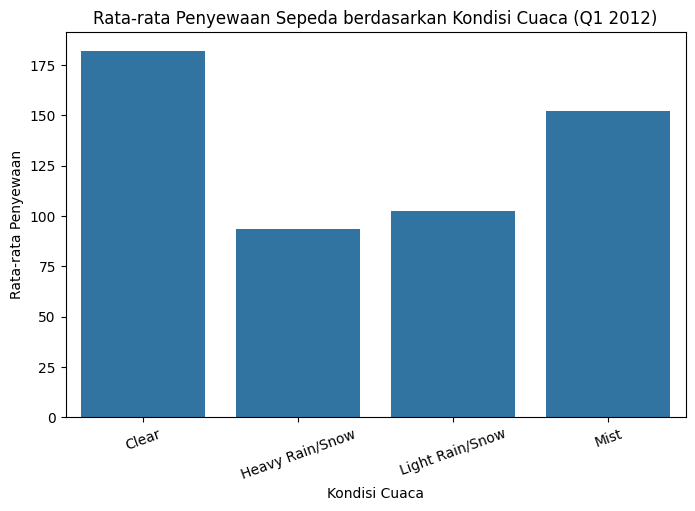

In [122]:
import matplotlib.pyplot as plt
import seaborn as sns

q1_2012 = df_hour[(df_hour['yr'] == 1) & (df_hour['mnth'].isin([1,2,3]))]

weather_avg = q1_2012.groupby('weathersit')['cnt'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=weather_avg, x='weathersit', y='cnt')

plt.title('Rata-rata Penyewaan Sepeda berdasarkan Kondisi Cuaca (Q1 2012)')
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Rata-rata Penyewaan')
plt.xticks(rotation=20)

plt.show()

Visualisasi ini menjawab pertanyaan mengenai perbandingan rata-rata jumlah penyewaan sepeda pada berbagai kondisi cuaca, khususnya antara cuaca cerah dan cuaca buruk pada kuartal pertama tahun 2012.

**Interpretasi Data**
- Rata-rata penyewaan sepeda tertinggi terjadi pada kondisi **cuaca cerah (Clear)** sebesar **182,17**.
- Pada kondisi cuaca buruk, yaitu **Light Rain/Snow** sebesar **102,38** dan **Heavy Rain/Snow** sebesar **93,50**.
- Terlihat adanya penurunan yang cukup signifikan dibandingkan kondisi cerah.
- Berdasarkan perhitungan, rata-rata penyewaan pada kondisi cuaca buruk mengalami penurunan sebesar sekitar **46,24%** dibandingkan cuaca cerah.

Hal ini menunjukkan bahwa kondisi cuaca memiliki pengaruh besar terhadap jumlah penyewaan sepeda, di mana cuaca yang kurang baik secara signifikan menurunkan minat penggunaan sepeda.

### Pertanyaan 2: Kapan (jam) terjadi penurunan jumlah penyewaan sepeda (cnt) paling signifikan (>20% di bawah rata-rata tahunan) selama tahun 2011–2012?

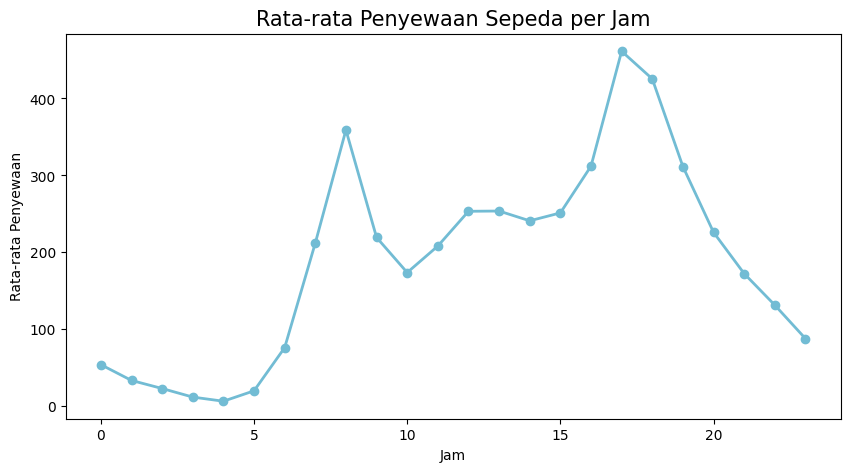

In [123]:
hour_avg = df_hour.groupby('hr')['cnt'].mean().reset_index()

plt.figure(figsize=(10,5))
plt.plot(hour_avg['hr'], hour_avg['cnt'], marker='o', linewidth=2, color="#72BCD4")

plt.title("Rata-rata Penyewaan Sepeda per Jam", fontsize=15)
plt.xlabel("Jam")
plt.ylabel("Rata-rata Penyewaan")

plt.show()

Visualisasi ini menjawab pertanyaan mengenai pola perubahan jumlah penyewaan sepeda berdasarkan jam untuk mengidentifikasi waktu dengan penurunan paling signifikan dibandingkan rata-rata.

**Interpretasi Data**
- Grafik menunjukkan bahwa jumlah penyewaan sepeda mengalami penurunan paling signifikan pada **jam dini hari**, khususnya pada **pukul 04.00** dengan rata-rata penyewaan hanya sekitar **6 sepeda** yang berada jauh di bawah rata-rata keseluruhan dan memenuhi kriteria **low demand** (<80%)**.
- Nilai rendah juga terlihat pada **pukul 03.00 dan 05.00**, yang memperkuat bahwa periode dini hari merupakan waktu dengan permintaan terendah secara konsisten.
- Setelah periode tersebut, jumlah penyewaan meningkat secara signifikan hingga mencapai puncak pada **jam pagi dan sore hari**, yang berkaitan dengan aktivitas harian pengguna.

Hal ini menunjukkan bahwa faktor waktu (jam) memiliki pengaruh yang sangat kuat terhadap tingkat penyewaan sepeda.


### Pertanyaan 3: Bagaimana pola perubahan jumlah penyewaan sepeda (cnt) sepanjang hari (hr) pada hari kerja dibandingkan akhir pekan selama bulan Juli–September 2011?

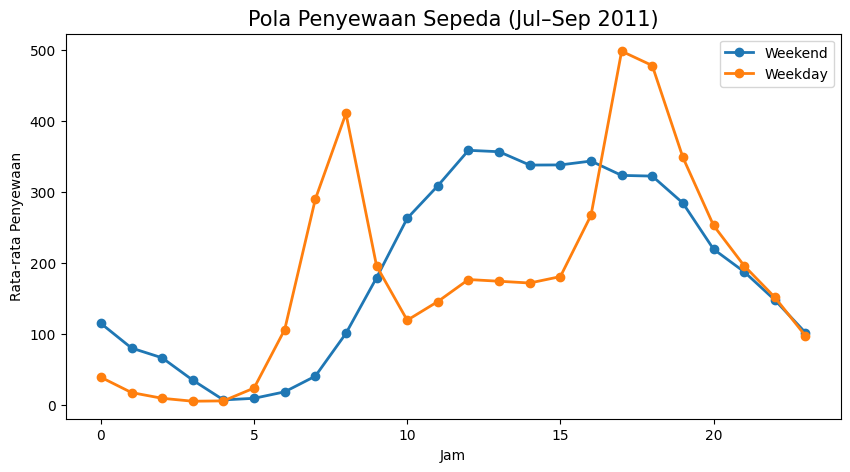

In [124]:
plt.figure(figsize=(10,5))

for key, grp in pattern.groupby('workingday'):
    label = "Weekday" if key == 1 else "Weekend"

    plt.plot(grp['hr'], grp['cnt'], marker='o', linewidth=2, label=label)

plt.title("Pola Penyewaan Sepeda (Jul–Sep 2011)", fontsize=15)
plt.xlabel("Jam")
plt.ylabel("Rata-rata Penyewaan")
plt.legend()

plt.show()

Visualisasi ini menjawab pertanyaan mengenai perbandingan pola perubahan jumlah penyewaan sepeda sepanjang hari antara hari kerja dan akhir pekan pada periode Juli-September 2011.

**Interpretasi Data**
- Grafik menunjukkan adanya perbedaan pola penyewaan sepeda yang jelas antara hari kerja dan akhir pekan.
- Pada **hari kerja**, terlihat dua puncak penyewaan, yaitu pada **pagi dan sore hari**, yang mencerminkan aktivitas commuting.
- Pada **akhir pekan**, penyewaan meningkat secara bertahap dan mencapai puncak pada **siang hingga sore hari**, yang menunjukkan pola penggunaan untuk rekreasi.
- Pada kedua kondisi, penyewaan sangat rendah pada dini hari, menunjukkan bahwa aktivitas penggunaan sepeda hampir tidak terjadi pada waktu tersebut.

Hal ini menunjukkan bahwa jenis hari (hari kerja atau akhir pekan) memengaruhi pola penggunaan sepeda secara signifikan.

### Pertanyaan 4: Apa faktor utama (suhu, kelembapan, dan kecepatan angin) yang paling berpengaruh terhadap peningkatan jumlah penyewaan sepeda (cnt) lebih dari 20% dibandingkan rata-rata selama tahun 2012??

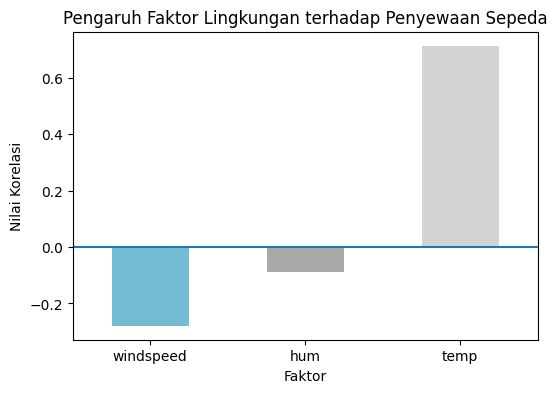

In [125]:
import matplotlib.pyplot as plt

corr = data_2012[['cnt','temp','hum','windspeed']].corr()['cnt'].drop('cnt')

# Plot
plt.figure(figsize=(6,4))
corr.sort_values().plot(kind='bar', color=["#72BCD4","#A9A9A9","#D3D3D3"])

plt.title("Pengaruh Faktor Lingkungan terhadap Penyewaan Sepeda")
plt.ylabel("Nilai Korelasi")
plt.xlabel("Faktor")

plt.axhline(0)
plt.xticks(rotation=0)

plt.show()

Visualisasi menunjukkan hubungan antara faktor lingkungan (suhu, kelembapan, dan kecepatan angin) terhadap jumlah penyewaan sepeda berdasarkan nilai korelasi.

Hasil analisis menunjukkan bahwa:

- **Suhu (temp)** memiliki korelasi positif paling tinggi terhadap jumlah penyewaan sepeda, yang berarti semakin tinggi suhu, semakin meningkat jumlah penyewaan.
- **Kelembapan (hum)** memiliki korelasi negatif yang lemah, menunjukkan bahwa peningkatan kelembapan cenderung sedikit menurunkan jumlah penyewaan.
- **Kecepatan angin (windspeed)** juga memiliki korelasi negatif, bahkan lebih besar dibandingkan kelembapan, yang menunjukkan bahwa angin yang lebih kencang dapat mengurangi minat penyewaan sepeda.

Hal ini menunjukkan bahwa **suhu** merupakan faktor lingkungan yang paling berpengaruh terhadap jumlah penyewaan sepeda, karena memiliki nilai korelasi paling tinggi dibandingkan faktor lainnya.

**Insight:** (Opsional)
- Jumlah penyewaan sepeda dipengaruhi oleh kombinasi faktor lingkungan dan pola waktu penggunaan.
- Suhu yang tinggi dan kondisi cuaca yang baik mendorong peningkatan penggunaan sepeda, sementara waktu penggunaan menunjukkan pola aktivitas pengguna yang berbeda antara hari kerja dan akhir pekan.

## Analisis Lanjutan (Opsional)

In [126]:
# Analisis Clustering Berdasarkan Tingkat Permintaan
df_hour['demand_level'] = pd.cut(
    df_hour['cnt'],
    bins=3,
    labels=['Low', 'Medium', 'High']
)
demand_analysis = df_hour.groupby('demand_level')[['temp','hum','windspeed']].mean()
demand_analysis

/tmp/ipykernel_2494/3809606622.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  demand_analysis = df_hour.groupby('demand_level')[['temp','hum','windspeed']].mean()


,temp,hum,windspeed
demand_level,,,
Low,19.190462,64.792066,12.493964
Medium,25.101720,54.491607,13.713121
High,26.332468,52.253191,13.891851


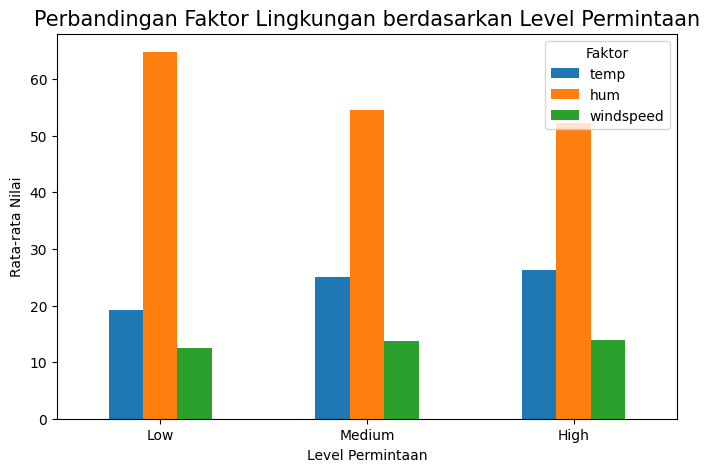

In [127]:
# Visualisasi Analisis Lanjutan
import matplotlib.pyplot as plt

demand_analysis.plot(kind='bar', figsize=(8,5))

plt.title("Perbandingan Faktor Lingkungan berdasarkan Level Permintaan", fontsize=15)
plt.xlabel("Level Permintaan")
plt.ylabel("Rata-rata Nilai")
plt.xticks(rotation=0)
plt.legend(title="Faktor")

plt.show()

Analisis lanjutan dilakukan dengan menggunakan teknik clustering sederhana (binning) untuk mengelompokkan data berdasarkan tingkat permintaan penyewaan sepeda (cnt) ke dalam tiga kategori, yaitu **Low**, **Medium**, dan **High**.

Berdasarkan hasil pengelompokan, diperoleh rata-rata kondisi lingkungan sebagai berikut:
1. **Low demand**:
- Suhu (sekitar **19,19**)
- Kelembapan (sekitar **64,79**)
- Kecepatan angin (sekitar **12,49**)
2. **Medium demand**:
- Suhu (sekitar **25,10**)
- Kelembapan (sekitar **54,49**)
- Kecepatan angin (sekitar **13,71**)
3. **High demand**:
- Suhu (sekitar **26,33**)
- Kelembapan (sekitar **52,25**)
- Kecepatan angin (sekitar **13,89**)

Hasil clustering menunjukkan bahwa **suhu** merupakan faktor paling dominan dalam membedakan tingkat permintaan penyewaan sepeda. Permintaan tinggi cenderung terjadi pada kondisi suhu yang lebih tinggi dan kelembapan yang lebih rendah.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Terdapat penurunan signifikan jumlah penyewaan sepeda pada kondisi cuaca buruk. Pada kuartal pertama tahun 2012, penyewaan sepeda menurun sekitar **46%** dibandingkan kondisi cuaca cerah. Hal ini menunjukkan bahwa cuaca merupakan faktor penting yang memengaruhi minat penggunaan sepeda.
- **Conclusion pertanyaan 2:** Penurunan jumlah penyewaan sepeda paling signifikan terjadi pada **pukul 04.00**, dengan rata-rata sekitar **6 sepeda**, yang berada jauh di bawah rata-rata keseluruhan. Hal ini menunjukkan bahwa periode dini hari merupakan waktu dengan permintaan terendah secara konsisten.
- **Conclusion pertanyaan 3:** Pola penyewaan sepeda berbeda antara hari kerja dan akhir pekan. Pada hari kerja, terdapat dua puncak penggunaan pada pagi dan sore hari yang mencerminkan aktivitas commuting. Sementara itu, pada akhir pekan, penyewaan meningkat pada siang hingga sore hari, yang menunjukkan pola penggunaan untuk rekreasi.
- **Conclusion pertanyaan 4:** Faktor utama yang paling berpengaruh terhadap peningkatan jumlah penyewaan sepeda adalah **suhu (temp)**. Penyewaan tinggi (>20% di atas rata-rata) cenderung terjadi pada kondisi suhu yang lebih tinggi, dengan kelembapan dan kecepatan angin yang relatif lebih rendah.




**Rekomendasi Action Item:**
- Strategi berdasarkan cuaca yaitu menyediakan promo atau diskon khusus saat cuaca buruk untuk mengurangi penurunan permintaan dan menyediakan fitur informasi cuaca dalam aplikasi untuk membantu pengguna merencanakan perjalanan.
- Optimalisasi waktu operasional dengan mengurangi jumlah sepeda operasional pada jam dini hari karena permintaan sangat rendah dan menambah ketersediaan sepeda pada jam sibuk (pagi dan sore) untuk memenuhi permintaan tinggi.
- Strategi berdasarkan hari (akhir pekan) dengan meningkatkan promosi untuk aktivitas.
- Strategi berdasarkan faktor lingkungan dengan meningkatkan ketersediaan sepeda pada kondisi suhu hangat/ideal karena permintaan cenderung meningkat.